In [1]:
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Sequence, Any
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader    
import math
import json
from itertools import permutations

In [2]:
import os, sys
sys.path.append('../../')

from pqcqec.utils.constants import QUBITS_FOR_GATES, QISKIT_GATES, GATE_IS_DIRECTIONAL


# Load Data

In [3]:
DATA_PATH = '../../nogit/no_rand_data/3q_10g_5blk_data/'
GOOD_DATA_PATH = DATA_PATH + 'good_fidelity/'
BAD_DATA_PATH = DATA_PATH + 'poor_fidelity/'

good_data = []
poor_data = []

for filename in os.listdir(GOOD_DATA_PATH):
    with open(GOOD_DATA_PATH + filename, 'r') as f:
        token_dict = json.load(f)
        good_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
        f.close()

for filename in os.listdir(BAD_DATA_PATH):
    with open(BAD_DATA_PATH + filename, 'r') as f:
        token_dict = json.load(f)
        poor_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
        f.close()

print(f"Number of good data samples: {len(good_data)}")
print(f"Number of poor data samples: {len(poor_data)}")

Number of good data samples: 9840
Number of poor data samples: 161


# Tokenizer for Data

In [4]:
# ----------------------------
# Tokenization (super simple)
# ----------------------------
def build_gate_vocab(gateset) -> Dict[str, int]:
    """Build a small gate->id vocab (id starts at 1; 0 is PAD)."""
    gates = set()
    for gate in gateset:
        gates.add(gate.lower())
    gate2id = {g: i+1 for i, g in enumerate(sorted(gates))}
    return gate2id

def encode_circuit(
    circuit: List[Tuple[str, List[int]]],
    gate2id: Dict[str, int],
    max_arity: int = 2
) -> Tuple[List[int], List[List[int]]]:
    """
    Encode a circuit into:
      gate_ids: [L] with 0=PAD
      qubit_ids: [L, max_arity] with 0=PAD; stores (q+1)
    """
    gate_ids: List[int] = []
    qubit_ids: List[List[int]] = []
    for gate, qs, _ in circuit:
        gid = gate2id[gate.lower()]
        gate_ids.append(gid)
        row = [0]*max_arity
        for j, q in enumerate(qs[:max_arity]):
            row[j] = q + 1  # 0 reserved for PAD
        qubit_ids.append(row)
    return gate_ids, qubit_ids

# ----------------------------
# Decode (reverse tokenization)
# ----------------------------
def decode_circuit(
    gate_ids,
    qubit_ids,
    *,
    gate2id: Optional[Dict[str, int]] = None,
    id2gate: Optional[Dict[int, str]] = None,
    max_arity: int = 2,
) -> List[List[Any]]:
    """
    Reverse of encode_circuit.
    - Skips PAD gate ids (0).
    - Converts qubit ids (q+1) back to q; ignores 0s.
    - Returns entries as [gate:str, [qubits:int...], []].
    Provide either id2gate or gate2id.
    """
    # Build id->gate map if not provided
    if id2gate is None:
        if gate2id is None:
            raise ValueError('Provide either id2gate or gate2id to decode_circuit')
        id2gate = {v: k for k, v in gate2id.items()}

    # Convert tensors to lists if needed
    try:
        import torch  # type: ignore
        if isinstance(gate_ids, torch.Tensor):
            gate_ids = gate_ids.detach().cpu().tolist()
        if isinstance(qubit_ids, torch.Tensor):
            qubit_ids = qubit_ids.detach().cpu().tolist()
    except Exception:
        pass

    out: List[List[Any]] = []
    for gid, qrow in zip(gate_ids, qubit_ids):
        gid = int(gid)
        if gid == 0:
            # skip PAD positions
            continue
        gate = id2gate.get(gid)
        if gate is None:
            raise KeyError(f'Unknown gate id: {gid}')
        # collect non-pad qubits, convert (q+1)->q
        qs: List[int] = []
        for idx in list(qrow)[:max_arity]:
            qi = int(idx)
            if qi > 0:
                qs.append(qi - 1)
        out.append([gate, qs, []])
    return out



In [5]:
class SimpleCircuitDataset(Dataset):
    def __init__(self, token_data: List[Tuple[List[int], List[List[int]], Any, Any]]):
        self.token_data = token_data

    def __len__(self):
        return len(self.token_data)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        gate_ids, qubit_ids, params, fidelity = self.token_data[idx]
        return (
            torch.tensor(gate_ids, dtype=torch.long),
            torch.tensor(qubit_ids, dtype=torch.long),
            torch.tensor(params, dtype=torch.float),
            torch.tensor(fidelity, dtype=torch.float)
        )


In [6]:
GATESET = ['x', 'h', 'cx', 'cz', 'z']
gate2id = build_gate_vocab(GATESET)
gate2id

{'cx': 1, 'cz': 2, 'h': 3, 'x': 4, 'z': 5}

In [7]:
token_data_list = []
for data in good_data:
    circuit, params, fidelity = data
    gate_ids, qubit_ids = encode_circuit(circuit, gate2id)
    token_data_list.append((gate_ids, qubit_ids, params, fidelity))

print(len(token_data_list))

9840


In [8]:
qc_dataset = SimpleCircuitDataset(token_data_list)


In [9]:
TRAIN_SZ = 0.8
VAL_SZ = 0.1
TEST_SZ = 0.1
BATCH_SIZE = 64

total_size = len(qc_dataset)
train_size = int(TRAIN_SZ * total_size)
val_size = int(VAL_SZ * total_size)
test_size = total_size - train_size - val_size
qc_train_dataset, qc_val_dataset, qc_test_dataset = torch.utils.data.random_split(qc_dataset, [train_size, val_size, test_size])

qc_train_dataloader = DataLoader(qc_train_dataset, batch_size=BATCH_SIZE, shuffle=True, )
qc_val_dataloader = DataLoader(qc_val_dataset, batch_size=BATCH_SIZE, shuffle=False, )
qc_test_dataloader = DataLoader(qc_test_dataset, batch_size=BATCH_SIZE, shuffle=False, )




In [10]:
decodetest = qc_dataset[0]
gate_id, qubit_id, params, fid = decodetest
cops = decode_circuit(gate_id, qubit_id, gate2id=gate2id)
print(cops)

[['cz', [0, 1], []], ['x', [0], []], ['cz', [1, 0], []], ['cz', [1, 2], []], ['z', [1], []], ['h', [1], []], ['z', [0], []], ['cz', [2, 1], []], ['cz', [0, 2], []], ['z', [1], []], ['z', [1], []], ['cz', [0, 2], []], ['cz', [2, 1], []], ['z', [0], []], ['h', [1], []], ['z', [1], []], ['cz', [1, 2], []], ['cz', [1, 0], []], ['x', [0], []], ['cz', [0, 1], []]]


# Transformer

In [10]:
# ----------------------------
# Model (tiny Transformer)
# ----------------------------
class TinyQCCircuitModel(nn.Module):
    def __init__(
        self,
        num_gates_vocab: int,
        num_qubits: int,
        output_shape: Sequence[int],
        d_model: int = 64,
        n_heads: int = 2,
        n_layers: int = 1,
        dim_ff: int = 128,
        dropout: float = 0.1,
        max_len: int = 1024,
        max_arity: int = 2,
    ):
        super().__init__()
        self.d_model = d_model
        self.max_arity = max_arity
        self.output_shape = tuple(output_shape)
        self.output_dim = int(math.prod(output_shape))

        # +1 to include PAD=0
        self.gate_embed = nn.Embedding(num_gates_vocab + 1, d_model, padding_idx=0)
        self.qubit_embed = nn.Embedding(num_qubits + 1, d_model, padding_idx=0)
        self.pos_embed = nn.Embedding(max_len, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, self.output_dim)

        self._init_params()

    def _init_params(self):
        nn.init.xavier_uniform_(self.gate_embed.weight)
        nn.init.xavier_uniform_(self.qubit_embed.weight)
        nn.init.xavier_uniform_(self.head.weight)
        if self.gate_embed.padding_idx is not None:
            with torch.no_grad():
                self.gate_embed.weight[self.gate_embed.padding_idx].zero_()
        if self.qubit_embed.padding_idx is not None:
            with torch.no_grad():
                self.qubit_embed.weight[self.qubit_embed.padding_idx].zero_()

    def forward(
        self,
        gate_ids: torch.Tensor,       # Long[B, L] or Long[L]
        qubit_ids: torch.Tensor,      # Long[B, L, max_arity] or Long[L, max_arity]
        key_padding_mask: Optional[torch.Tensor] = None # Bool[B, L] or Bool[L] (True where PAD)
    ) -> torch.Tensor:
        # Handle single input case by adding batch dimension
        if gate_ids.dim() == 1:
            gate_ids = gate_ids.unsqueeze(0)  # [L] -> [1, L]
            qubit_ids = qubit_ids.unsqueeze(0)  # [L, max_arity] -> [1, L, max_arity]
            if key_padding_mask is not None:
                key_padding_mask = key_padding_mask.unsqueeze(0)  # [L] -> [1, L]

        B, L = gate_ids.shape
        device = gate_ids.device

        # Embeddings
        g_vec = self.gate_embed(gate_ids)                          # [B, L, D]
        q_vec = self.qubit_embed(qubit_ids).sum(dim=2)             # [B, L, D]  (sum over involved qubits)
        pos = self.pos_embed(torch.arange(L, device=device))       # [L, D]
        pos = pos.unsqueeze(0).expand(B, L, -1)                    # [B, L, D]

        x = g_vec + q_vec + pos                                    # [B, L, D]

        # Transformer encoder (key_padding_mask: True where pad)
        x = self.encoder(x, src_key_padding_mask=(key_padding_mask if key_padding_mask is not None else None)) # [B, L, D]

        # Mean pool over sequence (masked if a mask is provided)
        if key_padding_mask is None:
            pooled = x.mean(dim=1)                                           # [B, D]
        else:
            lengths = (~key_padding_mask).sum(dim=1).clamp_min(1).unsqueeze(-1)  # [B,1]
            mask = (~key_padding_mask).float().unsqueeze(-1)                      # [B,L,1]
            pooled = (x * mask).sum(dim=1) / lengths                              # [B, D]

        z = self.norm(pooled)                                                 # [B, D]
        y = self.head(z)                                                      # [B, output_dim]
        return y.view(B, *self.output_shape)


In [11]:
NUM_QUBITS = 3
NUM_GATES = 2 * 10
GATE_BLOCKS = 5
PQC_GATES = ['rz', 'rx', 'rz']
OUTPUT_SHAPE = (int(NUM_GATES // GATE_BLOCKS), NUM_QUBITS, len(PQC_GATES))


In [12]:
q_model = TinyQCCircuitModel(num_gates_vocab=len(gate2id), num_qubits=NUM_QUBITS, output_shape=OUTPUT_SHAPE, max_len=NUM_GATES)

# Train

In [13]:
# Basic training setup
import os
# Enable CPU fallback for missing MPS ops (safer on macOS)
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
q_model = q_model.to(device)

criterion = nn.MSELoss()  # regress to PQC params
optimizer = torch.optim.Adam(q_model.parameters(), lr=1e-3, weight_decay=1e-4)
max_epochs = 1000  # adjust as needed
grad_clip = 1.0

def make_pad_mask(batch_gate_ids: torch.Tensor):
    """Return None to avoid MPS nested-tensor path (sequences equal length).
    """
    return None


In [14]:
def cosine_loss(pred_angles: torch.Tensor, target_angles: torch.Tensor) -> torch.Tensor:
    """
    Computes cosine loss between predicted and target angles.
    """
    cos_loss = 1 - torch.cos(pred_angles - target_angles)
    return cos_loss.mean()

def run_epoch(model, dataloader, train: bool = True):
    model.train(train)
    total_loss = 0.0
    n_batches = 0
    for batch in dataloader:
        gate_ids, qubit_ids, params, fidelity = batch
        gate_ids = gate_ids.to(device)
        qubit_ids = qubit_ids.to(device)
        params = params.to(device).float()

        pad_mask = make_pad_mask(gate_ids)
        with torch.set_grad_enabled(train):
            pred = model(gate_ids, qubit_ids, key_padding_mask=pad_mask)
            loss = cosine_loss(pred, params)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

train_hist = []
val_hist = []
for epoch in range(1, max_epochs + 1):
    train_loss = run_epoch(q_model, qc_train_dataloader, train=True)
    val_loss = run_epoch(q_model, qc_val_dataloader, train=False)
    train_hist.append(float(train_loss))
    val_hist.append(float(val_loss))
    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')


Epoch 01 | train_loss=0.9996 | val_loss=1.0015
Epoch 02 | train_loss=0.9974 | val_loss=1.0010
Epoch 03 | train_loss=0.9953 | val_loss=0.9998
Epoch 04 | train_loss=0.9944 | val_loss=0.9983
Epoch 05 | train_loss=0.9929 | val_loss=0.9970
Epoch 06 | train_loss=0.9924 | val_loss=0.9976
Epoch 07 | train_loss=0.9914 | val_loss=0.9975
Epoch 08 | train_loss=0.9901 | val_loss=0.9986
Epoch 09 | train_loss=0.9882 | val_loss=0.9991
Epoch 10 | train_loss=0.9876 | val_loss=0.9998
Epoch 11 | train_loss=0.9863 | val_loss=0.9973
Epoch 12 | train_loss=0.9848 | val_loss=0.9982
Epoch 13 | train_loss=0.9835 | val_loss=0.9957
Epoch 14 | train_loss=0.9825 | val_loss=0.9964
Epoch 15 | train_loss=0.9818 | val_loss=0.9958
Epoch 16 | train_loss=0.9814 | val_loss=1.0001
Epoch 17 | train_loss=0.9806 | val_loss=0.9966
Epoch 18 | train_loss=0.9800 | val_loss=0.9968
Epoch 19 | train_loss=0.9796 | val_loss=0.9965
Epoch 20 | train_loss=0.9788 | val_loss=0.9952
Epoch 21 | train_loss=0.9787 | val_loss=0.9928
Epoch 22 | tr

# Plot Loss

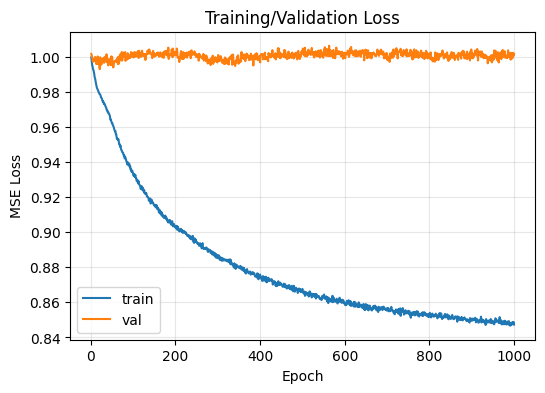

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_hist) + 1) if 'train_hist' in globals() else []
plt.figure(figsize=(6,4))
if epochs:
    plt.plot(epochs, train_hist, label='train')
    plt.plot(epochs, val_hist, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    print('Run the training cell first to populate train_hist/val_hist.')
plt.show()


In [16]:
# Quick test-set evaluation
q_model.eval()
with torch.no_grad():
    test_loss = 0.0
    n_batches = 0
    for batch in qc_test_dataloader:
        gate_ids, qubit_ids, params, fidelity = batch
        gate_ids = gate_ids.to(device)
        qubit_ids = qubit_ids.to(device)
        params = params.to(device).float()
        pad_mask = make_pad_mask(gate_ids)
        pred = q_model(gate_ids, qubit_ids, key_padding_mask=pad_mask)
        loss = criterion(pred, params)
        test_loss += loss.item()
        n_batches += 1
    test_loss /= max(n_batches, 1)
print(f'Test MSE: {test_loss:.4f}')


Test MSE: 13.4094


# Testing Model with Zero State

In [ ]:
def interleave_tensor_pqc_in_circuit(base_ops:list, qubits:int, blocks:int, pqc_gates:list, params:list):
    """Interleave PQC operations into the base circuit."""
    interleaved_circuit = []
    # print(params.shape)
    for i, op in enumerate(base_ops):
        # print(i, op)
        interleaved_circuit.append(op)
        if (i + 1) % blocks == 0:
            k = (i + 1) // blocks - 1
            # print(f"Interleaving PQC operations for block {k}")
            for q in range(qubits):
                for j, g in enumerate(pqc_gates):
                    # print(g, q, (k,q,j), params[k, q, j])
                    interleaved_circuit.append((g, [q], params[k, q, j].detach().numpy()))
    return interleaved_circuit

In [ ]:
from pqcqec.noise.simple_noise import PennylaneNoisyGates
from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.training.jax_loss_functions import jax_pure_state_fidelity

import jax.numpy as jnp

noise_model = PennylaneNoisyGates()
# NUM_QUBITS = 5
ZERO_STATE = jnp.zeros((2 ** NUM_QUBITS,), dtype=jnp.complex64).at[0].set(1.0)


In [ ]:
q_model.eval()  # Set the model to evaluation mode
test_fid_model = []
test_fid_default = []
for i, data in enumerate(qc_train_dataloader):

    gate_id, qubit_id, params, fid = data
    circuit_ops = decode_circuit(gate_id, qubit_id, gate2id=gate2id)
    # circuit_ops = [(op[0], op[1], []) for op in circuit_ops]  # Add params placeholder from the circuit ops
    pqc_circuit = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, params[0])

    gate_id = gate_id.to(device)
    qubit_id = qubit_id.to(device)

    input_ids = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)

    pred_theta = q_model(input_ids, attention_mask=attention_mask)[0]
    pred_theta = sin_cos_to_angles(pred_theta).to('cpu')
    # print(pred_theta)
    # pred_theta = decode_von_mises_parameters(pred_params)['mean_angle_rad'].to(torch.device('cpu'))
    circuit_interleaved = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pred_theta)

    measured_modelPQC = run_circuit_with_noise_model(circuit_interleaved, ZERO_STATE, noise_model, NUM_QUBITS)
    measured_defaultPQC = run_circuit_with_noise_model(pqc_circuit, ZERO_STATE, noise_model, NUM_QUBITS)

    # print(ZERO_STATE)
    # print(measured_modelPQC)

    fidelity_modelPQC = jax_pure_state_fidelity(ZERO_STATE, measured_modelPQC)
    fidelity_defaultPQC = jax_pure_state_fidelity(ZERO_STATE, measured_defaultPQC)

    test_fid_model.append(fidelity_modelPQC)
    test_fid_default.append(fidelity_defaultPQC)

    # print(f"Fidelity (Model PQC): {fidelity_modelPQC:.4e}, Fidelity (Default PQC): {fidelity_defaultPQC:.4e}")

In [ ]:
print(f"Net Fidelity (Model PQC): {jnp.mean(test_fid_model):.4e}, Net Fidelity (Default PQC): {jnp.mean(test_fid_default):.4e}")

Net Fidelity (Model PQC): 4.2062e-02, Net Fidelity (Default PQC): 9.9138e-01
